In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [5]:
#Check the first few rows of the dataset
df=  pd.read_csv(r"C:\Users\sucha\OneDrive\Desktop\Data Analysis & Gen AI\Module 11_CapstoneProject\Financial Fraud Detection  Anomaly Detection in Credit Card Transactions\cc_data.csv", sep=',', encoding='utf-8')
df.columns=data.columns.str.strip()
df.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,Issaquah,WA,98027,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,Andrews,IN,46702,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,Oconto Falls,WI,54154,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,Turner,MT,59542,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,Port Ewen,NY,12466,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [7]:
# What are the dimensions (number of rows and columns) of the dataset?
df.shape

(389002, 23)

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  int64  
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [16]:
# How many unique values are there in each categorical variable? 
categorical_cols= ['trans_date_trans_time','merchant','category','first','last','gender','street',
                   'state','city','job','dob','trans_num']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")

trans_date_trans_time: 293627
merchant: 693
category: 14
first: 352
last: 481
gender: 2
street: 979
state: 51
city: 890
job: 492
dob: 964
trans_num: 389002


In [14]:
# What is the distribution of numerical variables in the dataset?

['index', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [20]:
missing_values = print(df.isnull().sum())


index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [21]:
# statistical summary
df.describe()

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,3.745744e+05,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.100000e+01,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


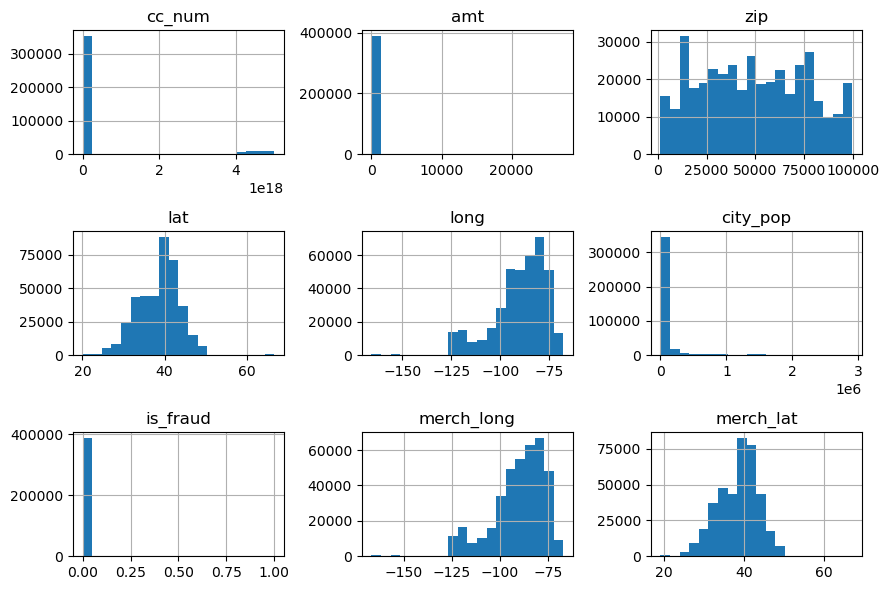

In [26]:
# Distribution of Numerical Variables
numerical_cols = ['cc_num','amt','zip','lat','long','city_pop','is_fraud','merch_long','merch_lat']

df[numerical_cols].hist(figsize=(9,6), bins=20)
plt.tight_layout()
plt.show()

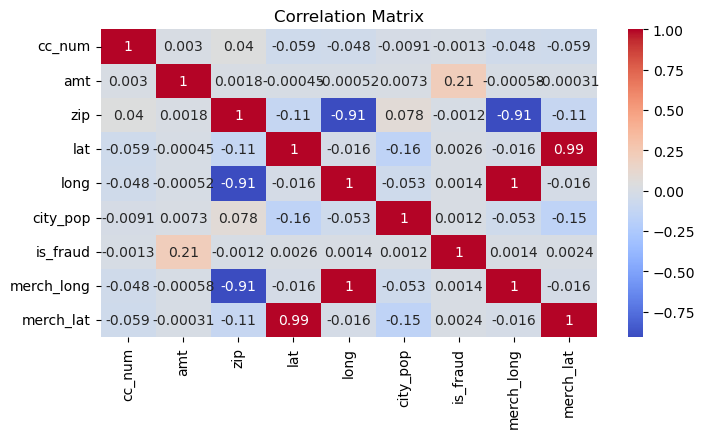

In [28]:
# Correlation Between Numerical Variables
numerical_cols = ['cc_num','amt','zip','lat','long','city_pop','is_fraud','merch_long','merch_lat']
plt.figure(figsize=(8,4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

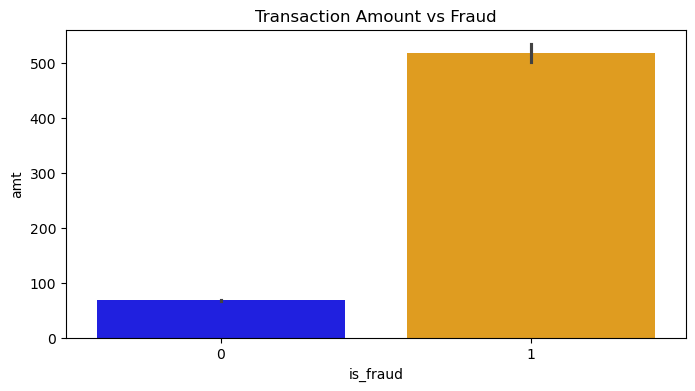

In [47]:
#  distribution of an amt differ across is_fraud categories using bar graph
plt.figure(figsize=(8,4))
sns.barplot(x='is_fraud', y='amt', data=df, palette=['blue', 'orange'])
plt.title("Transaction Amount vs Fraud")
plt.show()

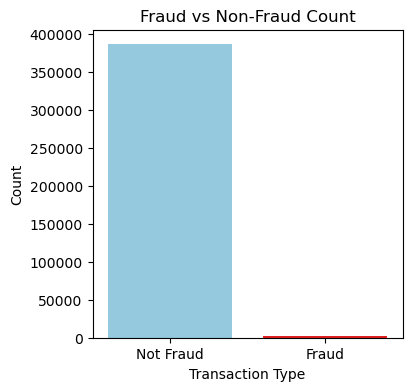

In [57]:
# Fraud Distribution using bar plot
plt.figure(figsize=(4,4))
sns.countplot(x='is_fraud', data=df, palette=['skyblue','red'])
plt.xticks([0,1], ['Not Fraud', 'Fraud'])
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Fraud vs Non-Fraud Count")

plt.show()

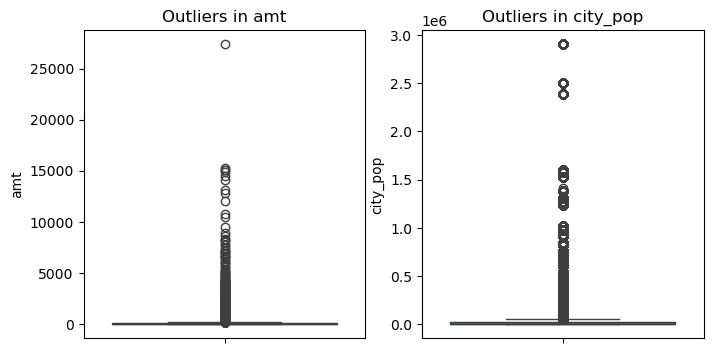

In [59]:
# Outlier Detection (amt & city_pop)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(df['amt'])
plt.title("Outliers in amt")

plt.subplot(1,2,2)
sns.boxplot(df['city_pop'])
plt.title("Outliers in city_pop")

plt.show()

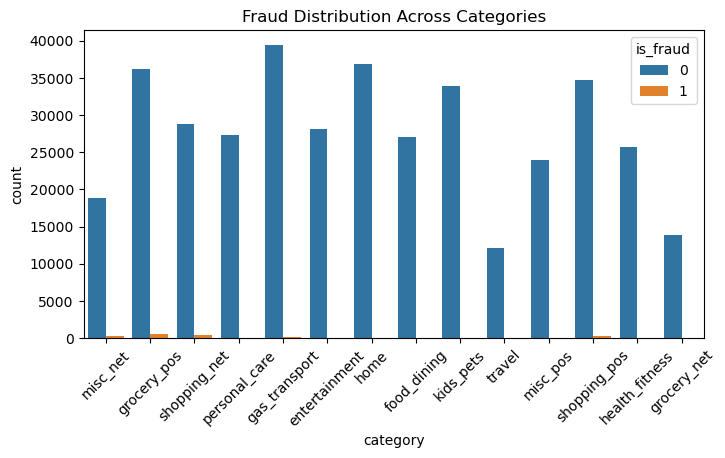

In [61]:
# Target Variable Distribution Across Categories
plt.figure(figsize=(8,4))
sns.countplot(x='category', hue='is_fraud', data=df)
plt.xticks(rotation=45)
plt.title("Fraud Distribution Across Categories")
plt.show()

In [62]:
df.groupby('job')['amt'].mean().sort_values(ascending=False).head(10)

job
Broadcast journalist                 1011.325000
Ship broker                           972.110000
Veterinary surgeon                    655.050000
Industrial buyer                      654.490000
Engineer, site                        638.912500
Personnel officer                     638.576667
Dancer                                586.450000
Careers adviser                       531.466000
Sales promotion account executive     529.648571
Air traffic controller                503.748000
Name: amt, dtype: float64

In [63]:
# checking for data consistency or errors

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Unique transaction IDs (if exists)
if 'trans_num' in df.columns:
    print("Unique transactions:", df['trans_num'].nunique())

Duplicate rows: 0
Unique transactions: 389002
